In [1]:
import glob
import os

import pandas as pd
import numpy as np

import tifffile as tf
from tifffile import imread
from tifffile import imwrite

import skimage
from skimage.measure import label
from skimage.measure import label
from skimage.filters import threshold_otsu
from skimage.morphology import remove_small_objects
from skimage.morphology import remove_small_holes

from scipy.ndimage import distance_transform_edt
from scipy.ndimage import gaussian_filter

from skimage import measure, segmentation, filters
from scipy import ndimage as ndi

import napari

import matplotlib.pyplot as plt
import matplotlib

from tqdm import tqdm

%load_ext autoreload
%autoreload 2
%matplotlib inline

In [68]:
# Import images

halo_dir = '/Volumes/gchao/bamfaile/Analysis/ACTB-KI/00_Batch20250731_vascular/D10/Unperturbed/Max_projections_separate/Halo' # Max_projections
halo_path = os.path.join(halo_dir,'*.tif')
halo_files = np.sort(glob.glob(halo_path))

halo_dir_series = '/Volumes/gmicro_prefect/gchao/bamfaile/Gitrepos_temp2/gchao_singlemolecule_tracking/runs/vascular_progenitors/03_predict/Batch20250731_D10/Unperturbed'
halo_path_series = os.path.join(halo_dir_series,'*.stk') 
halo_files_series = np.sort(glob.glob(halo_path_series))


print(len(halo_files))
print(len(halo_files_series))

11
11


In [69]:
# Read images into list

halo_images = []

for file in halo_files:
    image = imread(file)
    halo_images.append(image)

halo_images_series = []

for file in tqdm(halo_files_series):
    image = imread(file)
    halo_images_series.append(image)

print(len(halo_images))
print(len(halo_images_series))

100%|██████████| 11/11 [00:40<00:00,  3.65s/it]

11
11


In [70]:
halo_images_series[0].shape

(100, 1024, 1024)

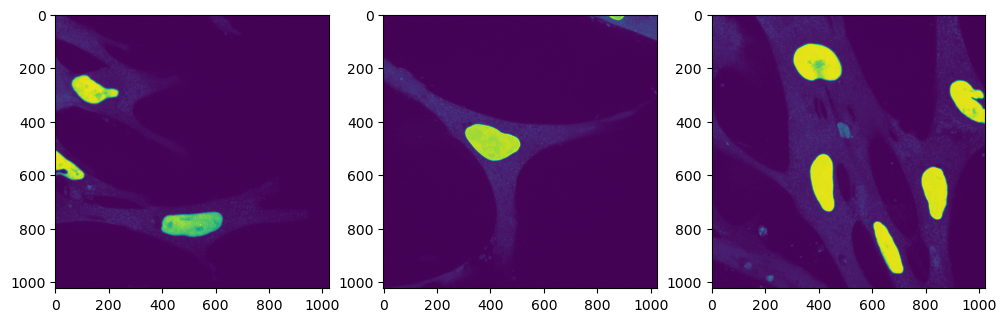

In [71]:
fig, ax = plt.subplots(1, 3, figsize = (12,4))
ax[0].imshow(halo_images[0])
ax[1].imshow(halo_images[1])
ax[2].imshow(halo_images[2])

### Nucleus segmentation

In [72]:
# Creates a stack and calculates the global otsu threshold which will be used to threshold all images

halo_stack = np.hstack(halo_images)
halo_otsu_nucleus = threshold_otsu(halo_stack)*0.35 # Factor to adjust otsu
print(halo_otsu_nucleus)

8319.85


In [73]:
# Segments nuclei based on merged otsu threshold for substraction from whole cell masks

nucleus_binary = []
for img in halo_images:
    mask = (img >= halo_otsu_nucleus) # Binary mask
    nucleus_binary.append(mask)

for i in range(len(nucleus_binary)):
    mask_label = label(nucleus_binary[i].astype(np.int64)) # Mask needs to be converted to integers for following operations
    nucleus_binary[i] = gaussian_filter(nucleus_binary[i].astype(float), sigma=5) > 0.5 # Smoothen edges

In [74]:
# Creates label images where small objects are removed for watershedding

nucleus_label = []

for img in halo_images:
    binary_mask = img >= halo_otsu_nucleus  # Create initial binary mask
    binary_mask = remove_small_objects(binary_mask, min_size=1000)
    smoothed_mask = gaussian_filter(binary_mask.astype(float), sigma=5) > 0.9  # Smooth edges
    smoothed_mask = remove_small_objects(smoothed_mask, min_size=1000)  # Remove small objects
    labeled_mask = label(smoothed_mask.astype(np.int64))  # Assign unique labels to smoothed mask
    labeled_mask = labeled_mask.astype(np.int32)
    nucleus_label.append(labeled_mask)

In [75]:
print(len(nucleus_label))
print(nucleus_label[0].dtype)

11
int32


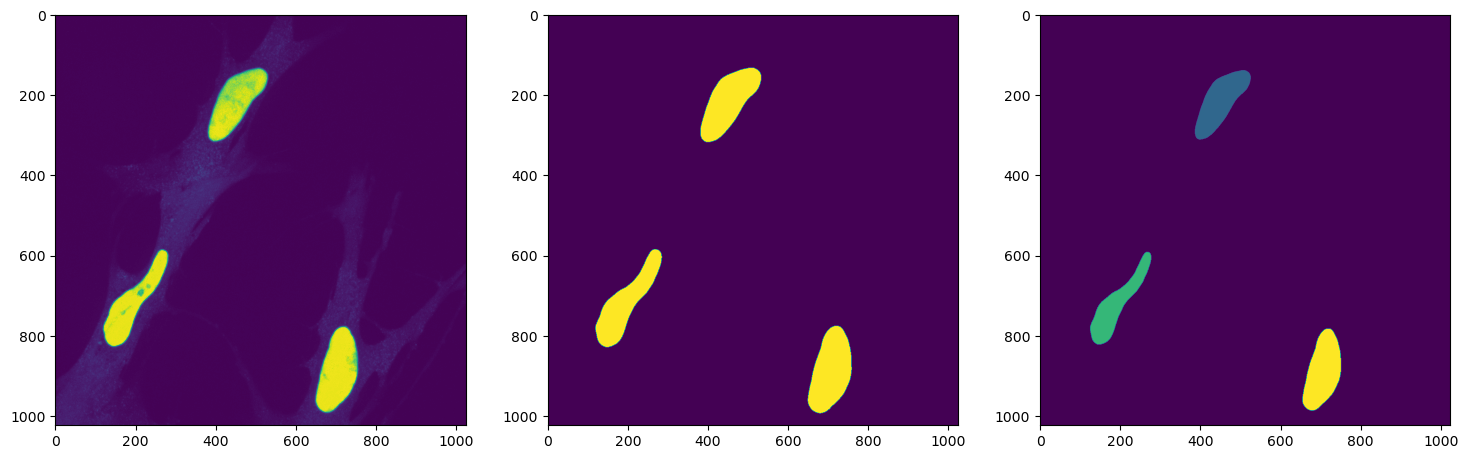

In [76]:
fig, ax = plt.subplots(1, 3, figsize = (18,6))
ax[0].imshow(halo_images[6])
ax[1].imshow(nucleus_binary[6])
ax[2].imshow(nucleus_label[6])

In [77]:
print(np.unique(nucleus_binary[0]))
print(np.unique(nucleus_label[0]))

[False  True]
[0 1 2 3]


### Whole cell segmentation

In [78]:
# Creates a stack and calculates the global otsu threshold which will be used to threshold all images

halo_stack = np.hstack(halo_images)
halo_otsu_whole_cell = threshold_otsu(halo_stack)*0.16 # Factor to adjust otsu
print(halo_otsu_whole_cell)

3803.36


In [79]:
otsu_thresholds_whole_cell = []

for image in halo_images:
    otsu = threshold_otsu(image)*0.12
    otsu_thresholds_whole_cell.append(otsu)
    print(otsu)

2728.08
3133.7999999999997
3236.04
3152.7599999999998
3148.68
2672.88
3082.2
2163.84
2768.64
2740.56
2718.8399999999997


In [80]:
# Segments merged_images based on separate otsu thresholds

whole_cell = []
for img, otsu in zip(halo_images, otsu_thresholds_whole_cell):
    mask = (img >= otsu) # Binary mask
    whole_cell.append(mask)

for i in range(len(whole_cell)):
    mask_label = label(whole_cell[i].astype(np.int64)) # Mask needs to be converted to integers for following operations
    whole_cell[i] = (remove_small_holes(whole_cell[i], area_threshold=1000) > 0)
    whole_cell[i] = gaussian_filter(whole_cell[i].astype(float), sigma=5) > 0.5 # Smoothen edges

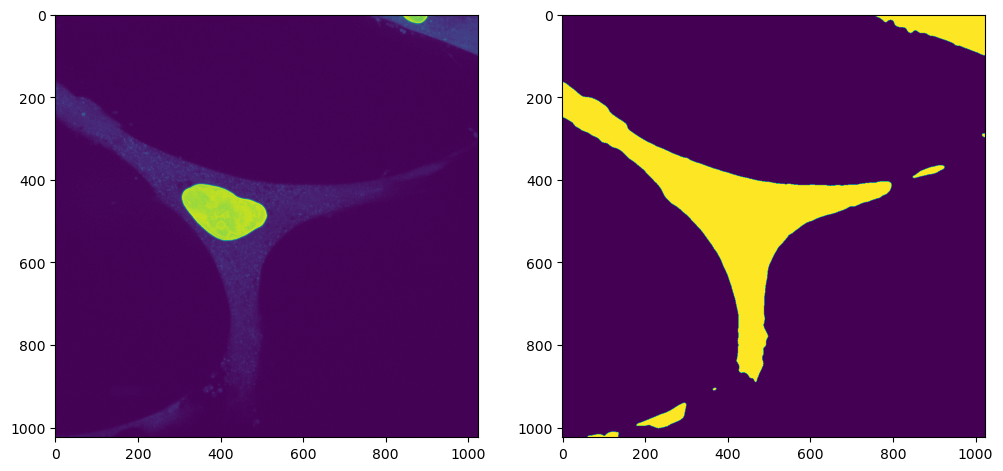

In [81]:
fig, ax = plt.subplots(1, 2, figsize = (12,6))
ax[0].imshow(halo_images[1])
ax[1].imshow(whole_cell[1])

### Cytoplasm mask generation

##### Watershedding from nucleus to separate cell masks

In [82]:
# Watershed using the nucleus as seed to separate the overlapping cell masks

mask_label=[]
distance_maps = []

for cell, nucleus in zip(whole_cell, nucleus_label):
    
    # Smooth the distance transform of the cell mask
    distance_map = ndi.distance_transform_edt(nucleus)
    smoothed_distance_map = filters.gaussian(distance_map, sigma=1)
    distance_maps.append(smoothed_distance_map)

    # Use the nuclei labels as markers
    markers = measure.label(nucleus)

    # Apply the watershed algorithm
    labels = segmentation.watershed(-smoothed_distance_map, markers, mask=cell)
    mask_label.append(labels)

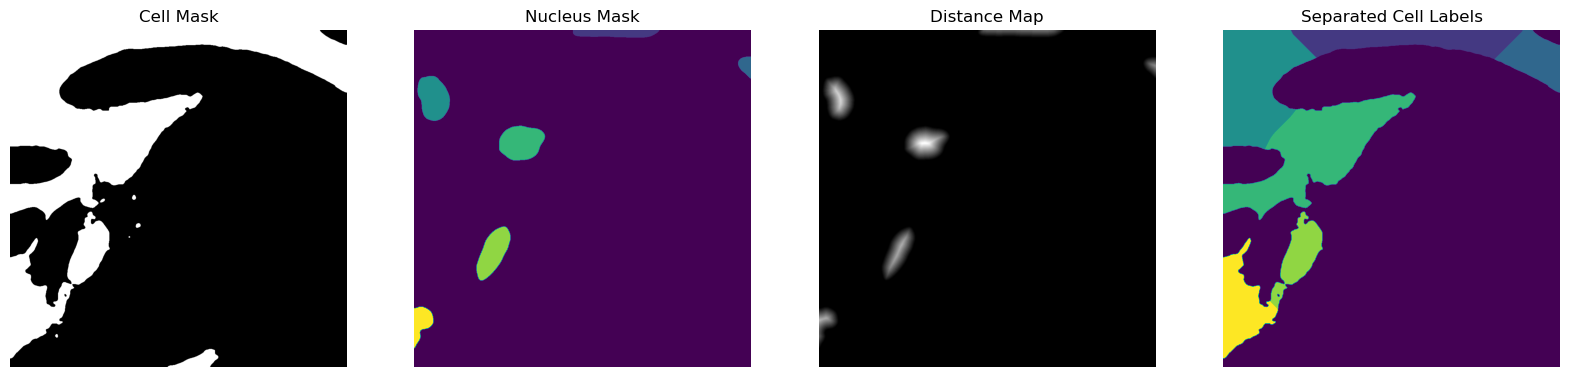

In [83]:
# Plotting the results including the distance map
fig, ax = plt.subplots(1, 4, figsize=(20, 5))

ax[0].imshow(whole_cell[-2], cmap='gray')
ax[0].set_title('Cell Mask')

ax[1].imshow(nucleus_label[-2], cmap='viridis')
ax[1].set_title('Nucleus Mask')

ax[2].imshow(distance_maps[-2], cmap='gray')
ax[2].set_title('Distance Map')

ax[3].imshow(mask_label[-2])
ax[3].set_title('Separated Cell Labels')

for a in ax:
    a.axis('off')

plt.show()

In [84]:
np.unique(mask_label[-2])

array([0, 1, 2, 3, 4, 5, 6], dtype=int32)

##### Substracting nucleus_label from mask_label

In [85]:
# Substract nucleus mask from cell mask and store as binary cytoplasm mask

def subtract_nucleus_from_cell(cell_mask, nucleus_mask):
    """
    Subtract the nucleus mask from the cell mask and return the cytoplasm mask.
    """
    # Create a copy of the cell mask to modify
    cytoplasm_mask = cell_mask.copy()
    
    # Set the areas where nucleus label is present to 0 in the cell mask
    cytoplasm_mask[nucleus_mask > 0] = 0
    
    return cytoplasm_mask

# List to store cytoplasm masks
mask_cytoplasm = []

for cell, nucleus in zip(mask_label, nucleus_label):
    # Subtract nucleus mask from cell mask
    cytoplasm_mask = subtract_nucleus_from_cell(cell, nucleus)
    
    mask_cytoplasm.append(cytoplasm_mask)

# Check results
for i, cytoplasm in enumerate(mask_cytoplasm):
    print(f"Unique values in cytoplasm mask {i}: {np.unique(cytoplasm)}")


Unique values in cytoplasm mask 0: [0 1 2 3]
Unique values in cytoplasm mask 1: [0 1 2]
Unique values in cytoplasm mask 2: [0 1 2 3 4 5]
Unique values in cytoplasm mask 3: [0 1]
Unique values in cytoplasm mask 4: [0 1 2]
Unique values in cytoplasm mask 5: [0 1 2 3]
Unique values in cytoplasm mask 6: [0 1 2 3]
Unique values in cytoplasm mask 7: [0 1 2 3 4 5 6 7 8 9]
Unique values in cytoplasm mask 8: [0 1 2 3 4 5 6 7 8]
Unique values in cytoplasm mask 9: [0 1 2 3 4 5 6]
Unique values in cytoplasm mask 10: [0 1 2]


In [86]:
# Check if mask_label and nucleus are lists of masks
print(f"Type of mask_label: {type(mask_label)}")
print(f"Type of nucleus: {type(nucleus_binary)}")

# Make sure both are lists (or arrays of binary masks)
if not isinstance(mask_label, list):
    print("Warning: mask_label is not a list.")
if not isinstance(nucleus_binary, list):
    print("Warning: nucleus is not a list.")

Type of mask_label: <class 'list'>
Type of nucleus: <class 'list'>


In [87]:
# Substracting nucleus_binary from mask_label by setting areas in the mask_label that correspond to nucleus_binary == 1 to 0
# Simply substrating would not work because the nucleus_binary are binary images while mask_label are label images
# This is necessary to remove artefacts (e.g. nuclear fragments) from the cytoplasm images that have been detected in the nucleus_binary images but removed
# from the nucleus_label images to not interfere with the watershedding

def subtract_nucleus_from_cell(cell_mask, nucleus_mask):
    """
    Subtract the nucleus mask from the cell mask and return the cytoplasm mask.
    """
    # Ensure the masks are 2D (in case they are 1D)
    if len(cell_mask.shape) != 2:
        print(f"Warning: cell_mask is not 2D, shape: {cell_mask.shape}")
    if len(nucleus_mask.shape) != 2:
        print(f"Warning: nucleus_mask is not 2D, shape: {nucleus_mask.shape}")

    # Create a copy of the cell mask to modify
    cytoplasm_mask = cell_mask.copy()
    
    # Set the areas where nucleus mask is 1 to 0 in the cell mask
    cytoplasm_mask[nucleus_mask == 1] = 0
    
    return cytoplasm_mask

# Loop through each cell and nucleus mask pair
mask_cytoplasm = []
for cell, nucleus in zip(mask_label, nucleus_binary):
    # Ensure that both are 2D masks
    if cell.ndim == 2 and nucleus.ndim == 2:
        cytoplasm_mask = subtract_nucleus_from_cell(cell, nucleus)
        mask_cytoplasm.append(cytoplasm_mask)
    else:
        print("Skipping mask pair due to wrong dimensions.")

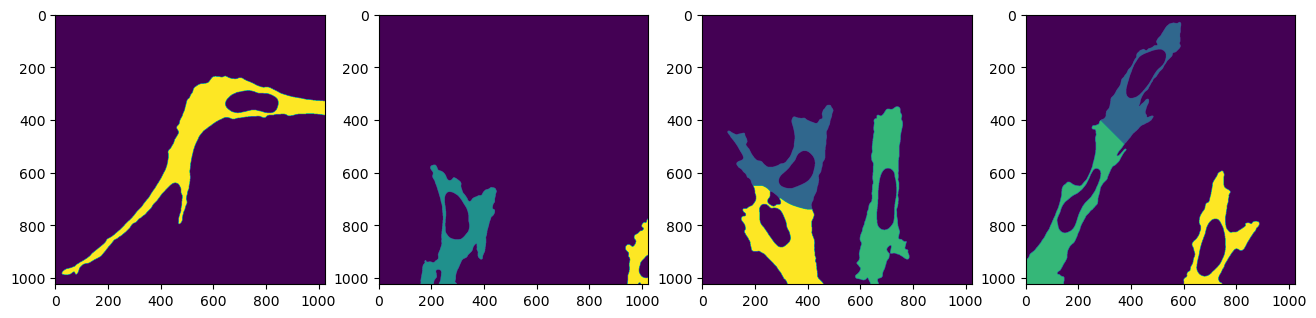

In [88]:
# Plot results of nucleus substraction

fig, ax = plt.subplots(1, 4, figsize = (16,4))
ax[0].imshow(mask_cytoplasm[3])
ax[1].imshow(mask_cytoplasm[4])
ax[2].imshow(mask_cytoplasm[5])
ax[3].imshow(mask_cytoplasm[6])

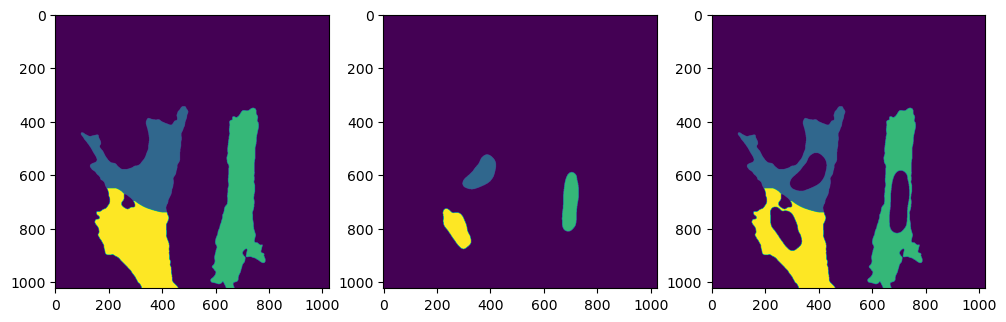

In [89]:
# Plot ROIs next to each other

fig, ax = plt.subplots(1, 3, figsize = (12,4))
ax[0].imshow(mask_label[5])
ax[1].imshow(nucleus_label[5])
ax[2].imshow(mask_cytoplasm[5])

In [90]:
print(mask_cytoplasm[0].dtype)
print(nucleus_label[0].dtype)
print(mask_label[0].dtype)

int32
int32
int32


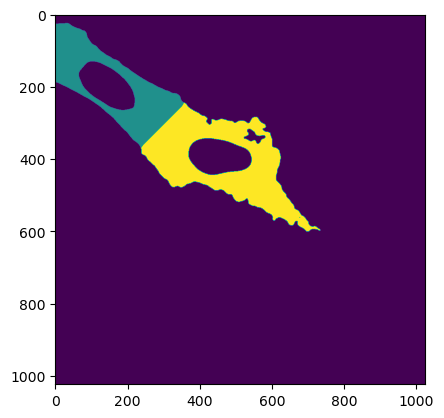

In [91]:
# Create copies of cytoplasm masks for manipulation in Napari

mask_cytoplasm_copy = mask_cytoplasm.copy()
plt.imshow(mask_cytoplasm_copy[-1])

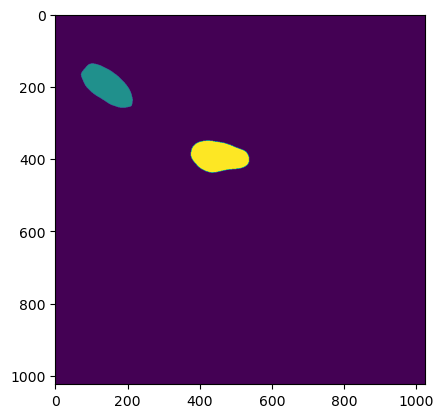

In [92]:
# Create copies of cytoplasm masks for manipulation in Napari

mask_nucleus_copy = nucleus_label.copy()
plt.imshow(mask_nucleus_copy[-1])

In [93]:
# Initializes Napari viewer

#viewer = napari.Viewer()

In [94]:
# Adds images to Napari viewer

for i, img in enumerate(halo_images_series):
    layer_name = f'image_{i}'  # Dynamically name each layer
    viewer.add_image(img, name=layer_name)

In [98]:
# Adds masks to Napari viewer

for i, img in enumerate(mask_cytoplasm_copy):
    layer_name = f'segmentation_{i}'  # Dynamically name each layer
    labels_layer = viewer.add_labels(img, name=layer_name, opacity=0.8)

In [97]:
# Adds masks to Napari viewer

for i, img in enumerate(mask_nucleus_copy):
    layer_name = f'segmentation_{i}'  # Dynamically name each layer
    labels_layer = viewer.add_labels(img, name=layer_name, opacity=1)

In [99]:
# Output directory max projections

output_dir = r'/Volumes/gchao/bamfaile/Analysis/ACTB-KI/00_Batch20250731_vascular/D10/Unperturbed/ROIs'

In [100]:
# Save cytoplasm, nucleus and cell masks

# Define the folder names
folders = ['Cytoplasm', 'Nucleus', 'Whole_cell']

# Create the folders if they don't exist
for folder in folders:
    folder_path = os.path.join(output_dir, folder)
    os.makedirs(folder_path, exist_ok=True)

# Function to save a max projection image
def save_max_projection_image(image, original_file, roi_name):
    # Extract the file name (without path)
    file_name = os.path.basename(original_file)
    
    # Extract the base name (remove everything after the last '_')
    base_name = file_name.rsplit('_', 1)[0]  # This splits at the last underscore
    
    # Create the new filename with the appropriate suffix (e.g., "_cytoplasm", "_nucleus", "_whole-cell")
    new_file_name = base_name + f"_{roi_name}.tif"
    
    # Define the output path
    output_file = os.path.join(output_dir, roi_name, new_file_name)
    
    # Check if file already exists to prevent overwriting
    if os.path.exists(output_file):
        print(f"Warning: {output_file} already exists! Skipping...")
        return
    
    # Save the max projection image to the corresponding folder
    tf.imwrite(output_file, image)
    print(f"Saved {output_file}")

# Now save the max projections for each channel using the same input images
for i, image_file in enumerate(halo_files):  # Use halo_files as the input image list
    # Save the max projection for each channel with the respective suffix
    save_max_projection_image(mask_cytoplasm[i], image_file, 'cytoplasm')
    save_max_projection_image(nucleus_label[i], image_file, 'nucleus')
    save_max_projection_image(mask_label[i], image_file, 'whole_cell')


Saved /Volumes/gchao/bamfaile/Analysis/ACTB-KI/00_Batch20250731_vascular/D10/Unperturbed/ROIs/cytoplasm/11_13z-0-5_640-20-100ms_200g_561-25-50ms-1000g_488-10-100ms-200g_1_cytoplasm.tif
Saved /Volumes/gchao/bamfaile/Analysis/ACTB-KI/00_Batch20250731_vascular/D10/Unperturbed/ROIs/nucleus/11_13z-0-5_640-20-100ms_200g_561-25-50ms-1000g_488-10-100ms-200g_1_nucleus.tif
Saved /Volumes/gchao/bamfaile/Analysis/ACTB-KI/00_Batch20250731_vascular/D10/Unperturbed/ROIs/whole_cell/11_13z-0-5_640-20-100ms_200g_561-25-50ms-1000g_488-10-100ms-200g_1_whole_cell.tif
Saved /Volumes/gchao/bamfaile/Analysis/ACTB-KI/00_Batch20250731_vascular/D10/Unperturbed/ROIs/cytoplasm/12_13z-0-5_640-20-100ms_200g_561-25-50ms-1000g_488-10-100ms-200g_1_cytoplasm.tif
Saved /Volumes/gchao/bamfaile/Analysis/ACTB-KI/00_Batch20250731_vascular/D10/Unperturbed/ROIs/nucleus/12_13z-0-5_640-20-100ms_200g_561-25-50ms-1000g_488-10-100ms-200g_1_nucleus.tif
Saved /Volumes/gchao/bamfaile/Analysis/ACTB-KI/00_Batch20250731_vascular/D10/Unpe